In [3]:
import cv2

# Load Haar Cascades
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

smile_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_smile.xml"
)

# Start webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam")
else:
    print("Webcam started.")
    print("Press Q to stop.")

    while True:
        ret, frame = cap.read()

        if not ret:
            print("Error: Could not read webcam frame")
            break

        # Convert frame to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.3,
            minNeighbors=5,
            minSize=(80, 80)
        )

        for (x, y, w, h) in faces:

            # Draw face rectangle
            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (255, 0, 0),
                2
            )

            cv2.putText(
                frame,
                "Face",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255, 0, 0),
                2
            )

            # Region of Interest for face
            roi_gray = gray[y:y+h, x:x+w]
            roi_color = frame[y:y+h, x:x+w]

            # Detect eyes
            eyes = eye_cascade.detectMultiScale(
                roi_gray,
                scaleFactor=1.2,
                minNeighbors=5,
                minSize=(20, 20)
            )

            for (ex, ey, ew, eh) in eyes:

                cv2.rectangle(
                    roi_color,
                    (ex, ey),
                    (ex + ew, ey + eh),
                    (0, 255, 0),
                    2
                )

                cv2.putText(
                    roi_color,
                    "Eye",
                    (ex, ey - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    1
                )

            # Detect smile
            smiles = smile_cascade.detectMultiScale(
                roi_gray,
                scaleFactor=1.7,
                minNeighbors=20,
                minSize=(25, 25)
            )

            for (sx, sy, sw, sh) in smiles:

                cv2.rectangle(
                    roi_color,
                    (sx, sy),
                    (sx + sw, sy + sh),
                    (0, 0, 255),
                    2
                )

                cv2.putText(
                    roi_color,
                    "Smile",
                    (sx, sy - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 0, 255),
                    2
                )

        # Display webcam
        cv2.imshow(
            "Face, Eye and Smile Detection",
            frame
        )

        # Press Q to exit
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Release webcam
    cap.release()
    cv2.destroyAllWindows()

Webcam started.
Press Q to stop.


In [5]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model


# ==========================================
# 1. LOAD HAAR CASCADE MODELS
# ==========================================

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_eye.xml"
)

smile_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_smile.xml"
)


# ==========================================
# 2. LOAD GENDER MODEL
# ==========================================

gender_model = cv2.dnn.readNetFromCaffe(
    "deploy_gender.prototxt",
    "gender_net.caffemodel"
)

gender_labels = [
    "Male",
    "Female"
]


# ==========================================
# 3. LOAD EMOTION MODEL
# ==========================================

emotion_model = load_model(
    "emotion_model.h5"
)

emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]


# ==========================================
# 4. CHECK MODELS
# ==========================================

if face_cascade.empty():
    print("Face cascade not loaded!")

if eye_cascade.empty():
    print("Eye cascade not loaded!")

if smile_cascade.empty():
    print("Smile cascade not loaded!")


# ==========================================
# 5. START WEBCAM
# ==========================================

cap = cv2.VideoCapture(0)

if not cap.isOpened():

    print("Could not open webcam")

else:

    print("Webcam started")
    print("Press Q to exit")


    # ======================================
    # 6. MAIN LOOP
    # ======================================

    while True:

        ret, frame = cap.read()

        if not ret:
            print("Could not read frame")
            break


        # ==================================
        # Convert to grayscale
        # ==================================

        gray = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2GRAY
        )


        # ==================================
        # FACE DETECTION
        # ==================================

        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.3,
            minNeighbors=5,
            minSize=(80, 80)
        )


        # ==================================
        # PROCESS EACH FACE
        # ==================================

        for (x, y, w, h) in faces:


            # --------------------------------
            # Draw face rectangle
            # --------------------------------

            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (255, 0, 0),
                2
            )


            # --------------------------------
            # Face ROI
            # --------------------------------

            roi_gray = gray[y:y+h, x:x+w]

            roi_color = frame[y:y+h, x:x+w]


            # =================================
            # EYE DETECTION
            # =================================

            eyes = eye_cascade.detectMultiScale(
                roi_gray,
                scaleFactor=1.2,
                minNeighbors=5,
                minSize=(20, 20)
            )


            for (ex, ey, ew, eh) in eyes:

                cv2.rectangle(
                    roi_color,
                    (ex, ey),
                    (ex + ew, ey + eh),
                    (0, 255, 0),
                    2
                )


                cv2.putText(
                    roi_color,
                    "Eye",
                    (ex, ey - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    1
                )


            # =================================
            # SMILE DETECTION
            # =================================

            smiles = smile_cascade.detectMultiScale(
                roi_gray,
                scaleFactor=1.7,
                minNeighbors=20,
                minSize=(25, 25)
            )


            for (sx, sy, sw, sh) in smiles:

                cv2.rectangle(
                    roi_color,
                    (sx, sy),
                    (sx + sw, sy + sh),
                    (0, 0, 255),
                    2
                )


                cv2.putText(
                    roi_color,
                    "Smile",
                    (sx, sy - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 0, 255),
                    2
                )


            # =================================
            # GENDER RECOGNITION
            # =================================

            face_for_gender = frame[
                max(0, y):min(frame.shape[0], y+h),
                max(0, x):min(frame.shape[1], x+w)
            ]


            if face_for_gender.size > 0:

                blob = cv2.dnn.blobFromImage(
                    face_for_gender,
                    1.0,
                    (227, 227),
                    (78.4263377603,
                     87.7689143744,
                     114.895847746),
                    swapRB=False
                )


                gender_model.setInput(blob)

                gender_prediction = gender_model.forward()


                gender_index = gender_prediction[0].argmax()

                gender = gender_labels[gender_index]

                gender_confidence = (
                    gender_prediction[0][gender_index] * 100
                )


            # =================================
            # EMOTION RECOGNITION
            # =================================

            emotion_face = roi_gray


            if emotion_face.size > 0:

                emotion_face = cv2.resize(
                    emotion_face,
                    (48, 48)
                )

                emotion_face = emotion_face.astype(
                    "float32"
                ) / 255.0

                emotion_face = np.expand_dims(
                    emotion_face,
                    axis=-1
                )

                emotion_face = np.expand_dims(
                    emotion_face,
                    axis=0
                )


                emotion_prediction = emotion_model.predict(
                    emotion_face,
                    verbose=0
                )


                emotion_index = np.argmax(
                    emotion_prediction
                )


                emotion = emotion_labels[
                    emotion_index
                ]


                emotion_confidence = (
                    emotion_prediction[0][emotion_index]
                    * 100
                )


            # =================================
            # DISPLAY INFORMATION
            # =================================

            cv2.putText(
                frame,
                "Gender: " + gender,
                (x, y - 55),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                (255, 255, 0),
                2
            )


            cv2.putText(
                frame,
                "Emotion: " + emotion,
                (x, y - 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                (0, 255, 255),
                2
            )


        # ==================================
        # DISPLAY FRAME
        # ==================================

        cv2.imshow(
            "Face + Eye + Smile + Emotion + Gender",
            frame
        )


        # ==================================
        # PRESS Q TO EXIT
        # ==================================

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break


    # ======================================
    # RELEASE
    # ======================================

    cap.release()

    cv2.destroyAllWindows()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\dnn\src\caffe\caffe_io.cpp:1127: error: (-2:Unspecified error) FAILED: fs.is_open(). Can't open "deploy_gender.prototxt" in function 'cv::dnn::ReadProtoFromTextFile'


In [7]:
!pip install opencv-python numpy tensorflow

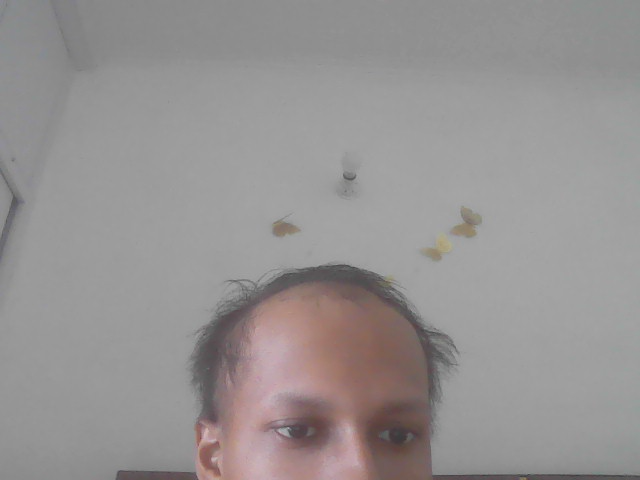

Camera stopped.


In [9]:
import cv2
from IPython.display import display, clear_output
from PIL import Image
import time

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

smile_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_smile.xml"
)

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Camera could not be opened.")
else:
    print("Camera started. Stop the cell to end.")

    try:
        while True:

            ret, frame = cap.read()

            if not ret:
                print("Could not read camera.")
                break

            # Convert to grayscale
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # Face detection
            faces = face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.3,
                minNeighbors=5
            )

            for (x, y, w, h) in faces:

                # Face rectangle
                cv2.rectangle(
                    frame,
                    (x, y),
                    (x + w, y + h),
                    (255, 0, 0),
                    2
                )

                cv2.putText(
                    frame,
                    "Face",
                    (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (255, 0, 0),
                    2
                )

                # Face region
                roi_gray = gray[y:y+h, x:x+w]
                roi_color = frame[y:y+h, x:x+w]

                # Eye detection
                eyes = eye_cascade.detectMultiScale(
                    roi_gray,
                    scaleFactor=1.2,
                    minNeighbors=5
                )

                for (ex, ey, ew, eh) in eyes:

                    cv2.rectangle(
                        roi_color,
                        (ex, ey),
                        (ex + ew, ey + eh),
                        (0, 255, 0),
                        2
                    )

                # Smile detection
                smiles = smile_cascade.detectMultiScale(
                    roi_gray,
                    scaleFactor=1.7,
                    minNeighbors=20
                )

                for (sx, sy, sw, sh) in smiles:

                    cv2.rectangle(
                        roi_color,
                        (sx, sy),
                        (sx + sw, sy + sh),
                        (0, 0, 255),
                        2
                    )

                    cv2.putText(
                        frame,
                        "Smile",
                        (x + sx, y + sy - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        (0, 0, 255),
                        2
                    )

            # Convert BGR to RGB
            frame_rgb = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            # Display in Jupyter
            clear_output(wait=True)
            display(Image.fromarray(frame_rgb))

            time.sleep(0.03)

    except KeyboardInterrupt:
        print("Camera stopped.")

    finally:
        cap.release()

In [11]:
!pip install opencv-python deepface

   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   -------------------------------------- - 1.8/1.9 MB 12.6 MB/s eta 0:00:01
   ---------------------------------------- 1.9/1.9 MB 8.7 MB/s eta 0:00:00
  Attempting uninstall: lz4
    Found existing installation: lz4 4.3.2
    Uninstalling lz4-4.3.2:
      Successfully uninstalled lz4-4.3.2


In [13]:
from deepface import DeepFace

print("DeepFace imported successfully")

ValueError: You have tensorflow 2.19.0 and this requires tf-keras package. Please run `pip install tf-keras` or downgrade your tensorflow.

In [ ]:
pip install tf-keras

In [ ]:
!pip install tf-keras

In [16]:
!pip install tf-keras

In [18]:
from deepface import DeepFace
print("DeepFace imported successfully")

ValueError: You have tensorflow 2.19.0 and this requires tf-keras package. Please run `pip install tf-keras` or downgrade your tensorflow.

In [20]:
pip uninstall tensorflow keras -y
pip install tensorflow==2.15
pip install tf-keras
pip install deepface

SyntaxError: invalid syntax (1481428478.py, line 1)

In [22]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [24]:
!pip install tensorflow

In [26]:
!pip install keras

In [ ]:
!